## Initial setup

In [1]:
# Import necessary modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import data
df = pd.read_csv('saturn_JPL_table.txt', sep='\t')  # tab delimiter is denoted as '\t'

### Define boolean arrays for filtering groups ###
# progrades
Kiviuq = (df['a'] <= 1.3e7) & (df['i'] >= 42) & (df['i'] <= 60)
Paaliaq = (df['a'] >= 1.4e7) & (df['a'] <= 1.6e7) & (df['i'] >= 42) & (df['i'] <= 60)
Siarnaq = (df['a'] >= 1.7e7) & (df['a'] <= 1.9e7) & (df['i'] >= 42) & (df['i'] <= 60)
Gallic = (df['a'] >= 1.6e7) & (df['a'] <= 2.4e7) & (df['i'] <= 42)
S2004S24 = (df['a'] >= 2.2e7) & (df['i'] <= 42)
# retrogrades
Norse = (df['i'] >= 90)
low_i = (df['i'] >= 90) & (df['i'] < 151.7)
Kari = (df['i'] >= 151.7) & (df['i'] < 157)
Mundilfari = (df['i'] >= 157) & (df['i'] < 172)
Phoebe = (df['i'] >= 172) & (df['i'] <= 180)

In [2]:
print(df)

      Satellite   Code           a      e      ω      M      i   node  \
0        Phoebe    609  12929400.0  0.164  240.3  308.0  175.2  192.7   
1          Ymir    619  22955600.0  0.338   45.3  167.5  172.3  204.5   
2       Paaliaq    620  14997700.0  0.378  237.6  318.2   48.5  353.2   
3        Tarvos    621  18216600.0  0.522  282.9   64.5   37.8   95.7   
4        Ijiraq    622  11344700.0  0.293   68.6   83.4   49.2  152.5   
..          ...    ...         ...    ...    ...    ...    ...    ...   
263  S2023_S_59  65299  20064000.0  0.467   10.5   66.5  169.5  337.9   
264  S2023_S_60  65300  17493700.0  0.206  258.1   93.9  170.7   81.3   
265  S2023_S_61  65301  18067700.0  0.557   37.7   75.3  158.0  303.7   
266  S2023_S_62  65302  14025900.0  0.467  206.6  241.3  155.6  355.8   
267  S2023_S_63  65303  18482600.0  0.266  299.9  225.6  165.0  101.8   

              P    Papsis     Pnode  Ref.  
0     550.30391   468.321   741.483  36.0  
1    1298.68190   154.500   267.800

## Additional setup: Prepare new dataframe with H and D

In [3]:
import pandas as pd
import re


def clean_satellite_name(raw_name):
    """
    Extracts and cleans the satellite name by:
    - Removing 'Saturn + Roman numeral'
    - Using the name inside parentheses when available
    - Removing slashes
    - Replacing spaces with underscores
    """
    raw_name = raw_name.strip()

    # Case 1: Use the name inside parentheses (e.g., Himalia)
    match = re.search(r"\((.*?)\)", raw_name)
    if match:
        name = match.group(1)
    else:
        # Case 2: Remove "Saturn <Roman Numeral>"
        name = re.sub(r"^Saturn\s+[IVXLCDM]+\s*", "", raw_name).strip()

    # Remove slashes
    name = name.replace("/", "")

    # Replace spaces with underscores
    name = name.replace(" ", "_")

    # Remove unwanted characters except letters, numbers, and underscores
    name = re.sub(r"[^A-Za-z0-9_]", "", name)

    # Remove duplicate underscores
    name = re.sub(r"_+", "_", name)

    # Remove leading/trailing underscores
    return name.strip("_")


def MPC_convert(file_path):
    """
    Extracts satellite names and H values from the text file
    and returns them as a pandas DataFrame.
    """
    satellite_names = []
    h_values = []
    current_satellite = None

    # Patterns to identify satellite names and H values
    satellite_pattern = re.compile(
        r"^(Saturn\s+[A-Z0-9IVXLCDM]+(?:\s*\(.*?\))?|S/\d{4}\s+S\s+\d+)",
        re.IGNORECASE
    )
    h_pattern = re.compile(r"\bH\s+([0-9]+(?:\.[0-9]+)?)")

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            # Detect satellite name lines
            sat_match = satellite_pattern.match(line)
            if sat_match:
                raw_name = sat_match.group(0)
                current_satellite = clean_satellite_name(raw_name)
                continue

            # Detect H values
            h_match = h_pattern.search(line)
            if h_match and current_satellite:
                satellite_names.append(current_satellite)
                h_values.append(float(h_match.group(1)))
                current_satellite = None

    # Create DataFrame
    df = pd.DataFrame({
        "Satellite": satellite_names,
        "H": h_values
    })

    return df

In [4]:
# Import MPC data; only read name and H
file_path = "saturn_MPC_table.txt"
df_MPC = MPC_convert(file_path)

# Display results
print(len(df_MPC))
print(df_MPC.iloc[42])

# Merge dataframes based on matching values in column
matches = df['Satellite'].isin(df_MPC['Satellite'])
print(matches[matches == False])  # make sure ALL names match with no "False" match flags

# Merge
DF = df.merge(df_MPC, on='Satellite')
print(f"Length of final merged dataframe:  len(DF) = {len(DF)}")  # Make sure the final merged DF length is same as JPL's
print(f"Does the final merged dataframe equal the original JPL dataframe length?\n{len(DF) == len(df)}")  # Make sure the final merged DF length is 107
# print(DF)

268
Satellite    Geirrod
H               15.9
Name: 42, dtype: object
Series([], Name: Satellite, dtype: bool)
Length of final merged dataframe:  len(DF) = 268
Does the final merged dataframe equal the original JPL dataframe length?
True


In [5]:
def H_to_D(H, albedo=0.04):
    '''
    Function that converts absolute magnitude (H) and albedo into diameter (in km).

    INPUT:
     - H
     - albedo (set to 0.04 by default)
    OUTPUT:
     - diameter (km)
    '''
    D = (1329/np.sqrt(albedo)) * 10**(-0.2*H)
    return D

# Add two new columns: diameter (km) and inverse diameter (1/D)
DF['Diameter (km)'] = H_to_D(DF['H'], albedo=0.04)
DF['1/D'] = 1/DF['Diameter (km)']

print(DF)

      Satellite   Code           a      e      ω      M      i   node  \
0        Phoebe    609  12929400.0  0.164  240.3  308.0  175.2  192.7   
1          Ymir    619  22955600.0  0.338   45.3  167.5  172.3  204.5   
2       Paaliaq    620  14997700.0  0.378  237.6  318.2   48.5  353.2   
3        Tarvos    621  18216600.0  0.522  282.9   64.5   37.8   95.7   
4        Ijiraq    622  11344700.0  0.293   68.6   83.4   49.2  152.5   
..          ...    ...         ...    ...    ...    ...    ...    ...   
263  S2023_S_59  65299  20064000.0  0.467   10.5   66.5  169.5  337.9   
264  S2023_S_60  65300  17493700.0  0.206  258.1   93.9  170.7   81.3   
265  S2023_S_61  65301  18067700.0  0.557   37.7   75.3  158.0  303.7   
266  S2023_S_62  65302  14025900.0  0.467  206.6  241.3  155.6  355.8   
267  S2023_S_63  65303  18482600.0  0.266  299.9  225.6  165.0  101.8   

              P    Papsis     Pnode  Ref.      H  Diameter (km)       1/D  
0     550.30391   468.321   741.483  36.0   6.7

# Polar plot for orbital elements

In [6]:
# Add new column for reduced semimajor axis (e6km)
DF['a_e6km'] = DF['a']/1e6

# DEFINE SATURN HILL RADIUS (in km)
AU = 149597870700 # in meters
a_Sat = 9.5826 * AU
e_Sat = 0.0565
M_Sat = 5.68317 * 10**26 # in kg
M_sun = 1.988416 * 10**30 # in kg
Hill_radius = a_Sat*(1-e_Sat)*(M_Sat/(3*(M_sun+M_Sat)))**(1/3) / 1000
Hill_radius_e6km = Hill_radius / 1e6

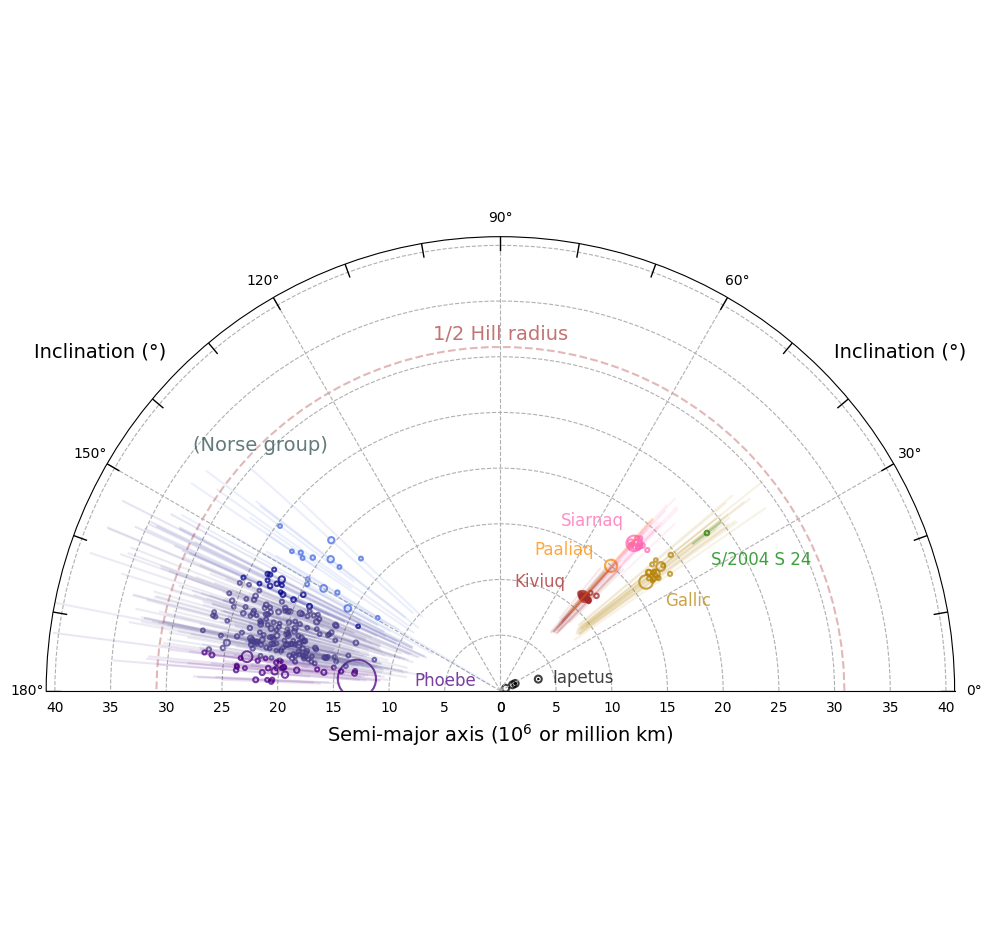

In [7]:
# global settings
size = 10  # figure size
alpha = 0.75  # point opacity
err_alpha = 0.1  # errorbar opacity
sf = 10  # scale factor
m = '.'  # marker style
fill = 'None'  # marker face (fill) color
lw = 1.5  # marker edge line width

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(size,size))

### PLOT POINTS ###
reg_a = np.array([527200, 1221900, 1481500, 3561700])/1e6
reg_i = np.deg2rad([26.73, 26.73, 26.73, 17.28])
reg_e = np.array([0.001, 0.029, 0.105, 0.028])
ax.scatter(reg_i, reg_a,
            s=sf*10, marker=m,
            facecolors=fill, edgecolors='k', lw=lw,
            alpha=alpha, label='Regular moons')
ax.errorbar(reg_i, reg_a,
            yerr = reg_a*reg_e,
            fmt = 'none', alpha = 1,
            c='k')
# progrades
ax.scatter(np.deg2rad(DF['i'][Kiviuq]), DF['a_e6km'][Kiviuq],
            s=sf*DF['Diameter (km)'][Kiviuq], marker=m,
            facecolors=fill, edgecolors='brown', lw=lw,
            alpha=alpha, label='Kiviuq')
ax.scatter(np.deg2rad(DF['i'][Paaliaq]), DF['a_e6km'][Paaliaq],
            s=sf*DF['Diameter (km)'][Paaliaq], marker=m,
            facecolors=fill, edgecolors='darkorange', lw=lw,
            alpha=alpha, label='Paaliaq')
ax.scatter(np.deg2rad(DF['i'][Siarnaq]), DF['a_e6km'][Siarnaq], 
            s=sf*DF['Diameter (km)'][Siarnaq], marker=m,
            facecolors=fill, edgecolors='hotpink', lw=lw,
            alpha=alpha, label='Siarnaq')
ax.scatter(np.deg2rad(DF['i'][Gallic & ~S2004S24]), DF['a_e6km'][Gallic & ~S2004S24], 
            s=sf*DF['Diameter (km)'][Gallic & ~S2004S24], marker=m,
            facecolors=fill, edgecolors='darkgoldenrod', lw=lw,
            alpha=alpha, label='Gallic')
ax.scatter(np.deg2rad(DF['i'][S2004S24]), DF['a_e6km'][S2004S24], 
            s=sf*DF['Diameter (km)'][S2004S24], marker=m,
            facecolors=fill, edgecolors='g', lw=lw,
            alpha=alpha, label='S/2004 S 24')
# retrogrades
'''
ax.scatter(np.deg2rad(DF['i'][Norse & ~low_i]), DF['a_e6km'][Norse & ~low_i], 
            s=sf*DF['Diameter (km)'][Norse & ~low_i], marker=m,
            facecolors=fill, edgecolors='dimgray', lw=lw,
            alpha=alpha, label='Norse')
'''
ax.scatter(np.deg2rad(DF['i'][low_i]), DF['a_e6km'][low_i], 
            s=sf*DF['Diameter (km)'][low_i], marker=m,
            facecolors=fill, edgecolors='royalblue', lw=lw,
            alpha=alpha, label='low-i')
ax.scatter(np.deg2rad(DF['i'][Kari]), DF['a_e6km'][Kari], 
            s=sf*DF['Diameter (km)'][Kari], marker=m,
            facecolors=fill, edgecolors='darkblue', lw=lw,
            alpha=alpha, label='Kari')
ax.scatter(np.deg2rad(DF['i'][Mundilfari]), DF['a_e6km'][Mundilfari], 
            s=sf*DF['Diameter (km)'][Mundilfari], marker=m,
            facecolors=fill, edgecolors='darkslateblue', lw=lw,
            alpha=alpha, label='Mundilfari')
ax.scatter(np.deg2rad(DF['i'][Phoebe]), DF['a_e6km'][Phoebe], 
            s=sf*DF['Diameter (km)'][Phoebe], marker=m,
            facecolors=fill, edgecolors='indigo', lw=lw,
            alpha=alpha, label='Phoebe')

### PLOT ECCENTRICITY ###
# progrades
ax.errorbar(np.deg2rad(DF['i'][Kiviuq]), DF['a_e6km'][Kiviuq],
            yerr = DF['a_e6km'][Kiviuq]*DF['e'][Kiviuq],
            fmt = 'none', alpha = err_alpha,
            c='brown')
ax.errorbar(np.deg2rad(DF['i'][Paaliaq]), DF['a_e6km'][Paaliaq],
            yerr = DF['a_e6km'][Paaliaq]*DF['e'][Paaliaq],
            fmt = 'none', alpha = 0.3,
            c='darkorange')
ax.errorbar(np.deg2rad(DF['i'][Siarnaq]), DF['a_e6km'][Siarnaq],
            yerr = DF['a_e6km'][Siarnaq]*DF['e'][Siarnaq],
            fmt = 'none', alpha = err_alpha,
            c='hotpink')
ax.errorbar(np.deg2rad(DF['i'][Gallic & ~S2004S24]), DF['a_e6km'][Gallic & ~S2004S24],
            yerr = DF['a_e6km'][Gallic & ~S2004S24]*DF['e'][Gallic & ~S2004S24],
            fmt = 'none', alpha = err_alpha,
            c='darkgoldenrod')
ax.errorbar(np.deg2rad(DF['i'][S2004S24]), DF['a_e6km'][S2004S24],
            yerr = DF['a_e6km'][S2004S24]*DF['e'][S2004S24],
            fmt = 'none', alpha = 0.3,
            c='g')
# retrogrades
'''
ax.errorbar(np.deg2rad(DF['i'][Norse & ~low_i]), DF['a_e6km'][Norse & ~low_i],
            yerr = DF['a'][Norse & ~low_i]*DF['e'][Norse & ~low_i],
            fmt = 'none', alpha = err_alpha,
            c='dimgray')
'''
ax.errorbar(np.deg2rad(DF['i'][low_i]), DF['a_e6km'][low_i],
            yerr = DF['a_e6km'][low_i]*DF['e'][low_i],
            fmt = 'none', alpha = err_alpha,
            c='royalblue')
ax.errorbar(np.deg2rad(DF['i'][Kari]), DF['a_e6km'][Kari],
            yerr = DF['a_e6km'][Kari]*DF['e'][Kari],
            fmt = 'none', alpha = err_alpha,
            c='darkblue')
ax.errorbar(np.deg2rad(DF['i'][Mundilfari]), DF['a_e6km'][Mundilfari],
            yerr = DF['a_e6km'][Mundilfari]*DF['e'][Mundilfari],
            fmt = 'none', alpha = err_alpha,
            c='darkslateblue')
ax.errorbar(np.deg2rad(DF['i'][Phoebe]), DF['a_e6km'][Phoebe],
            yerr = DF['a_e6km'][Phoebe]*DF['e'][Phoebe],
            fmt = 'none', alpha = err_alpha,
            c='indigo')


ax.set_rlim([0, 0.95*ax.get_rmax()])  # Fix the plot radius
#ax.set_rticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])  # Define radial ticks
#ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
ax.grid(True, linestyle='--', zorder=-10)


### Angle minor ticks ###
angletick = [ax.get_rmax()*1.05, ax.get_rmax() * 0.97]  # from outside the plot to slightyly interior to the border
# Iterate the points between 0 to 360 with step=10
for t in np.deg2rad(np.arange(0, 360, 10)):
    ax.plot([t, t], angletick, lw=1, color="black")


# Set angle bounds for plot
ax.set_thetamin(0)
ax.set_thetamax(180)

# Make radius axis labels on both left and right sides
ax.yaxis.set_tick_params(labelright=True)


# Add text labels for moon groups on top of the plot
# plt.text uses (angle [radians], radius)
## Progrades
plt.text(np.deg2rad(6), 7.5, "Iapetus", rotation=0, fontsize=12, ha='center', color='k', alpha=alpha)
plt.text(np.deg2rad(69), 10, "Kiviuq", rotation=0, fontsize=12, ha='center', color='brown', alpha=alpha)
plt.text(np.deg2rad(65), 13.5, "Paaliaq", rotation=0, fontsize=12, ha='center', color='darkorange', alpha=alpha)
plt.text(np.deg2rad(61), 17, "Siarnaq", rotation=0, fontsize=12, ha='center', color='hotpink', alpha=alpha)
plt.text(np.deg2rad(26), 26, "S/2004 S 24", rotation=0, fontsize=12, ha='center', color='g', alpha=alpha)
plt.text(np.deg2rad(24.5), 18.5, "Gallic", rotation=0, fontsize=12, ha='center', color='darkgoldenrod', alpha=alpha)
## Retrogrades)
plt.text(np.deg2rad(174), 5, "Phoebe", rotation=0, fontsize=12, ha='center', color='indigo', alpha=alpha)
plt.text(np.deg2rad(135), 30.5, "(Norse group)", rotation=0, fontsize=14, ha='center', color='darkslategray', alpha=alpha)


# label axes and title
#ax.set_xlabel("Semi-major axis (Saturn Hill radii)", rotation=0, size=14, labelpad=-170)
ax.set_xlabel(r"Semi-major axis ($10^6$ or million km)", rotation=0, size=14, loc='center', labelpad=-170*size/12)
plt.text(45*(np.pi/180), 1.04*ax.get_rmax(), "Inclination (°)", fontsize=14, ha='left', color='black')
plt.text(135*(np.pi/180), 1.04*ax.get_rmax(), "Inclination (°)", fontsize=14, ha='right', color='black')
#plt.legend(loc='upper center')

# Label half Hill radii
ax.plot(np.linspace(0, np.pi), np.ones_like(np.linspace(0, np.pi))*(Hill_radius_e6km/2),
        ls='--', c='brown', alpha=0.33, zorder=-10)
# plt.text uses (angle [radians], radius)
plt.text(np.pi/2, 1.01*Hill_radius_e6km/2, r"1/2 Hill radius",
         fontsize=14, ha='center', va='bottom', color='brown', alpha=0.66)

plt.tight_layout()
plt.savefig("Saturn_irregular_moons_polar_plot.svg", dpi=300, bbox_inches='tight')
plt.show()